In [267]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as ss
import pyarrow.parquet as pq

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [268]:
df = pd.read_parquet('../data/Cleaned_Transportation_Data.parquet')

In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype          
---  ------                          --------------  -----          
 0   gps_provider                    3526 non-null   object         
 1   booking_id                      3526 non-null   object         
 2   shipment_type                   3526 non-null   object         
 3   booking_date                    3526 non-null   datetime64[ns] 
 4   vehicle_registration            3526 non-null   object         
 5   origin_location                 3526 non-null   object         
 6   destination_location            3526 non-null   object         
 7   origin_location_latitude        3526 non-null   float64        
 8   origin_location_longitude       3526 non-null   float64        
 9   destination_location_latitude   3526 non-null   float64        
 10  destination_location_longitude  3526 non-null   float64     

## Route Cause Analysis: What factors need to poor on-time rate?

### EDA

#### Distribution

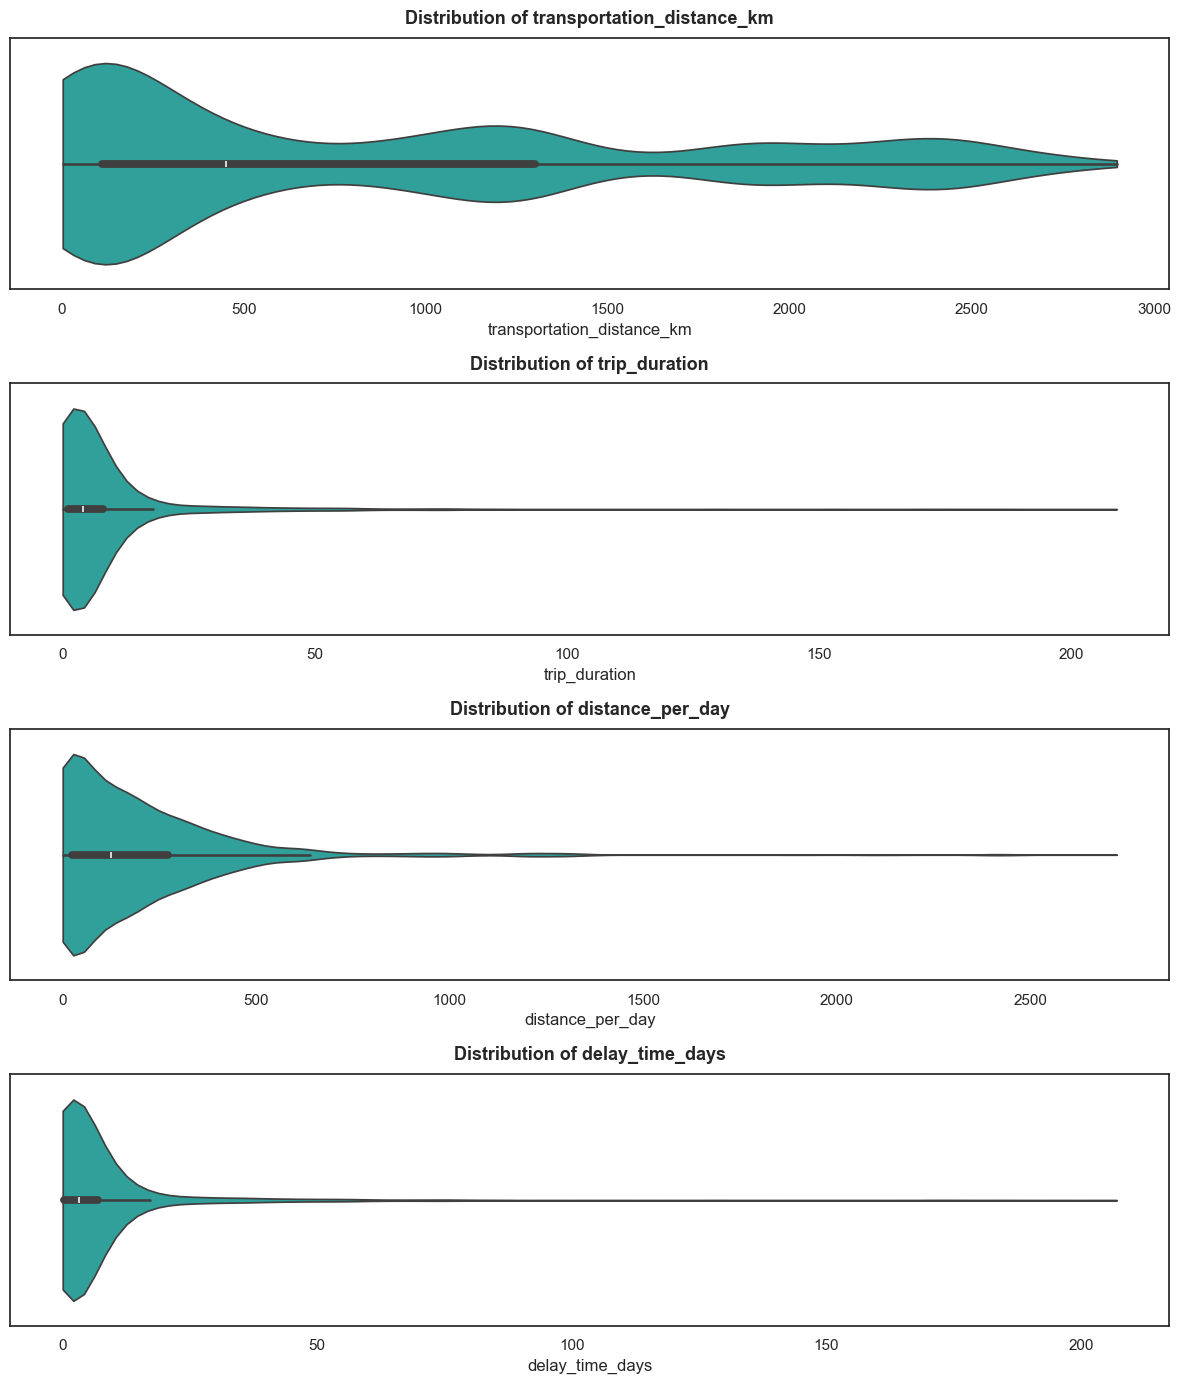

In [270]:
num_cols = [
    'transportation_distance_km', 
    'trip_duration', 
    'distance_per_day', 
    'delay_time_days'
]

cols_to_plot = [col for col in num_cols if col in df.columns]

fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(12, 3.5 * len(cols_to_plot)))
sns.set_theme(style='white')

if len(cols_to_plot) == 1:
    axes = [axes]

for i, col in enumerate(cols_to_plot):
    data_clean = df[col].dropna()
    
    sns.violinplot(
        x=data_clean, 
        color='lightseagreen', 
        inner='box', 
        cut=0, 
        ax=axes[i]
    )
    
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig('../material/numerical_variable_distribution.png', dpi=300)
plt.show()

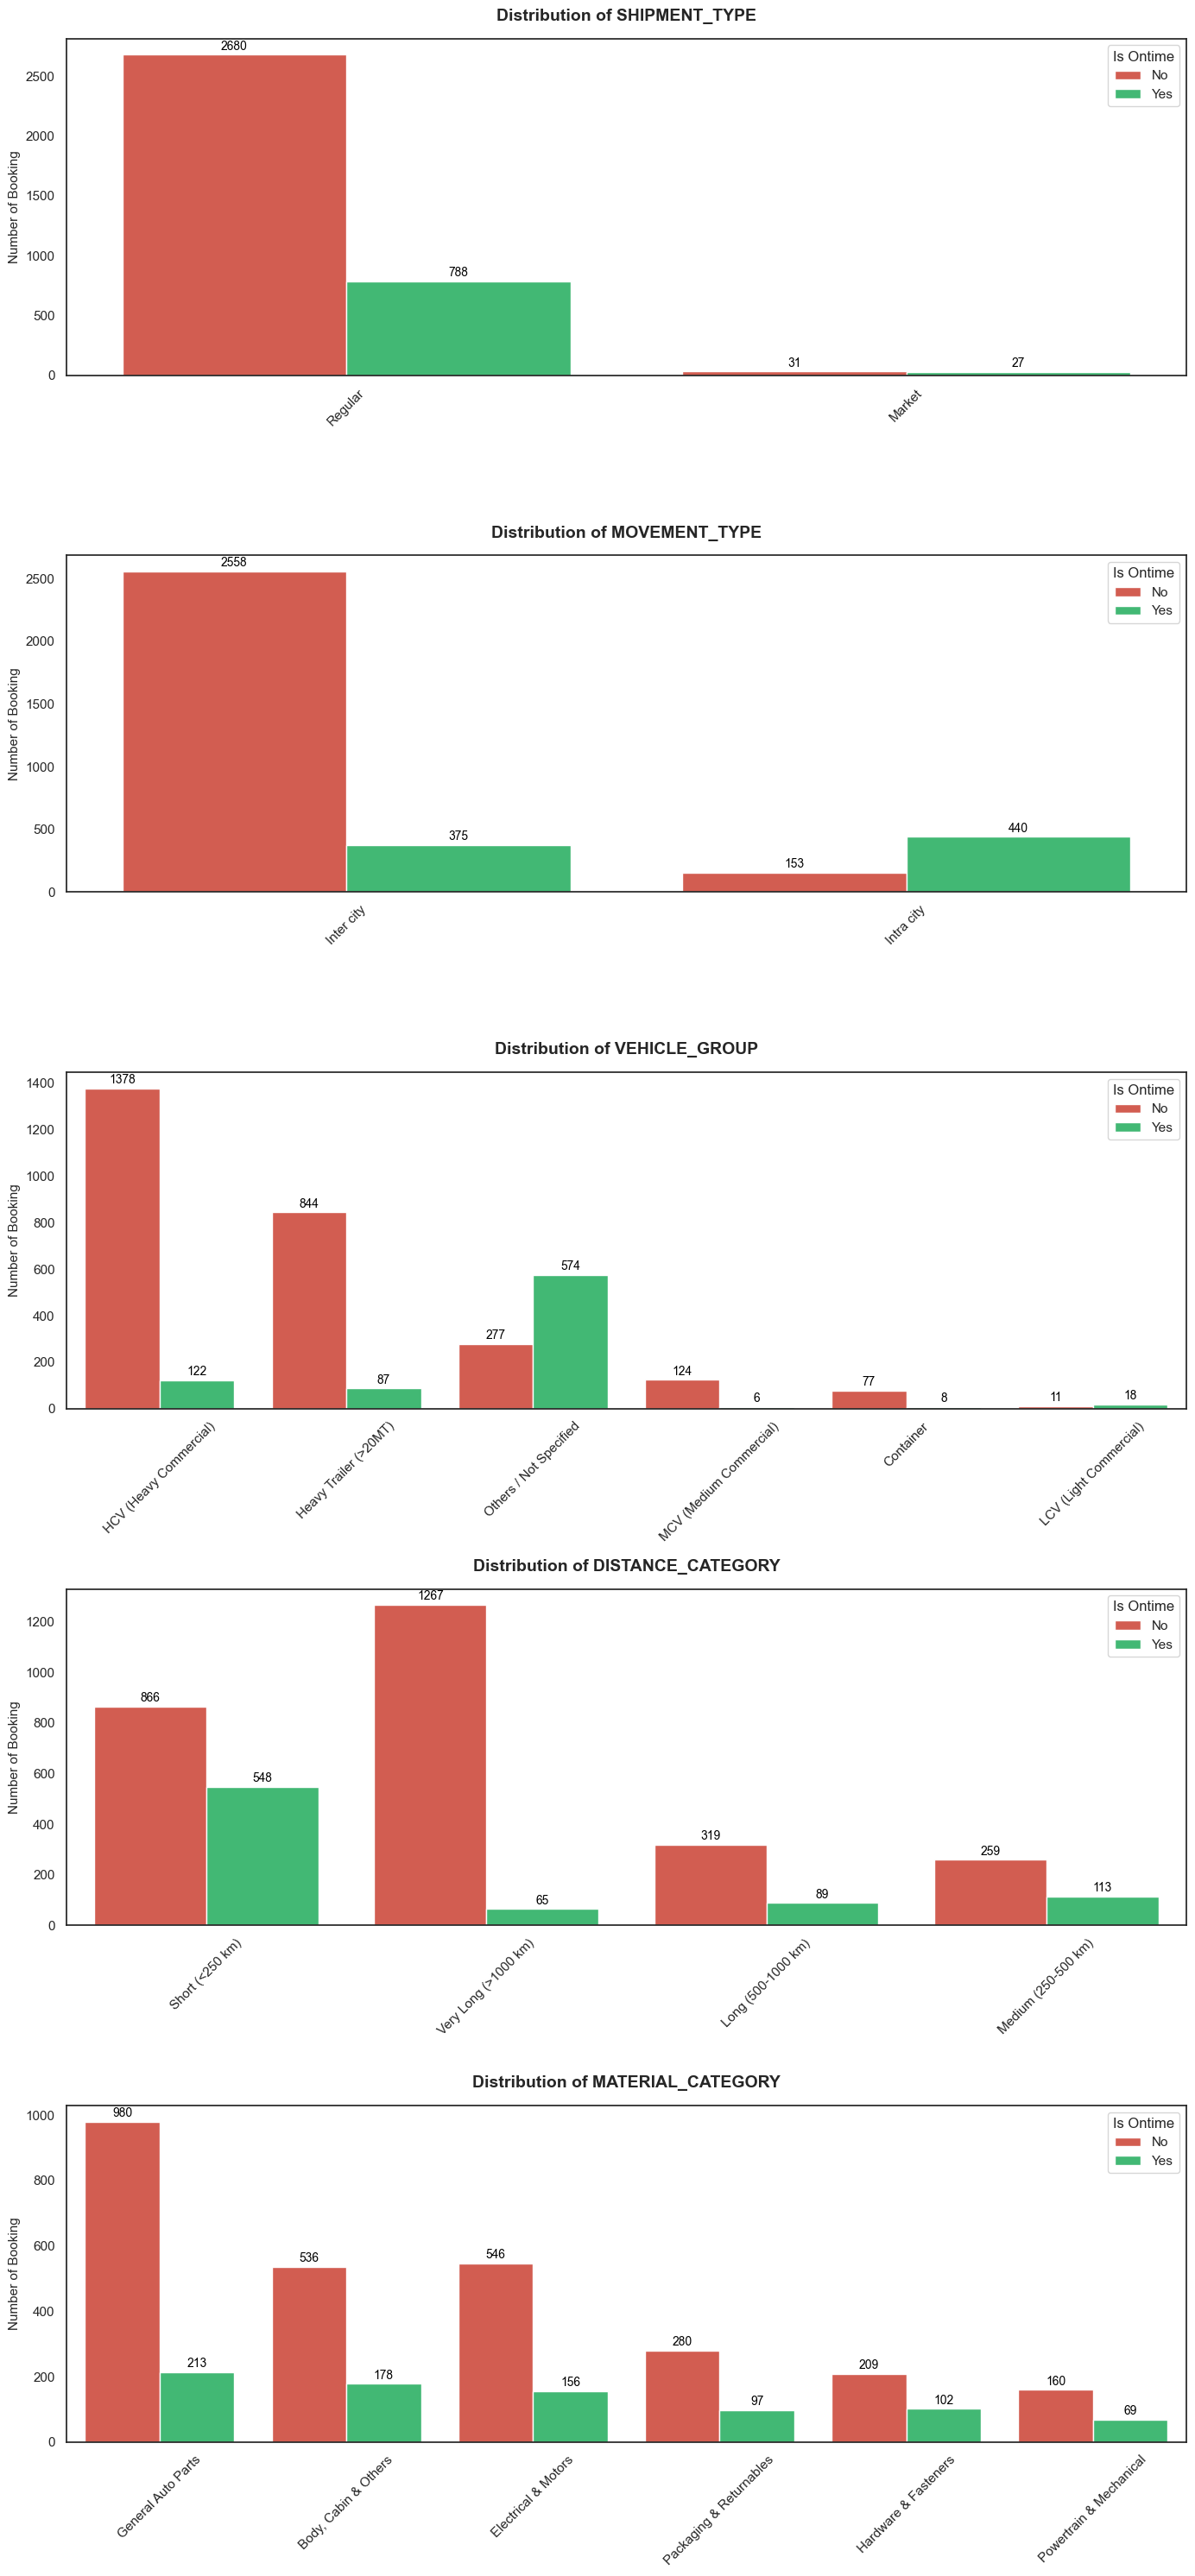

In [271]:
cat_cols = [
    'shipment_type', 
    'movement_type', 
    'vehicle_group', 
    'distance_category',
    'material_category'
]

cols_to_plot = [col for col in cat_cols if col in df.columns]

fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(14, 6 * len(cols_to_plot)))
sns.set_theme(style="whitegrid")

if len(cols_to_plot) == 1: axes = [axes]
for i, col in enumerate(cols_to_plot):
    order = df[col].value_counts().index
    
    ax = sns.countplot(
        data=df,
        x=col,
        hue='ontime',
        order=order,
        palette={'Yes': '#2ecc71', 'No': '#e74c3c'},
        ax=axes[i]
    )
    
    axes[i].set_title(f'Distribution of {col.upper()}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_ylabel('Number of Booking', fontsize=11)
    axes[i].set_xlabel('') 
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Is Ontime', loc='upper right')
    
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=10, color='black', 
                        xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.savefig('../material/categorical_variable_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Biviriate check

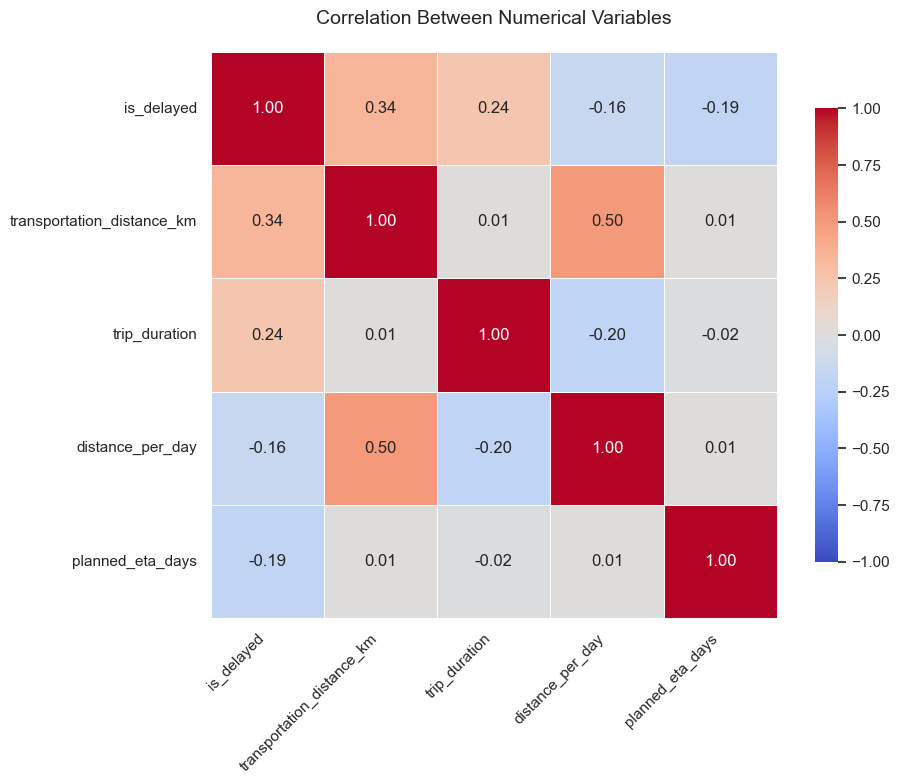

In [272]:
df['is_delayed'] = df['ontime'].map({'Yes': 0, 'No': 1})

df['planned_eta_days'] = df['planned_eta'].dt.total_seconds() / (24 * 3600)

numeric_features = [
    'is_delayed',             
    'transportation_distance_km',
    'trip_duration',
    'distance_per_day',        
    'planned_eta_days'             
]

cols_to_use = [col for col in numeric_features if col in df.columns]

corr_matrix = df[cols_to_use].corr(method='pearson')

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm", 
    vmin=-1, vmax=1,     
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Between Numerical Variables", pad=20, fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

--- CHI-SQUARE TEST RESULTS (P-VALUES) ---
- H0: shipment_type have effect on delay rate
- shipment_type  : p-value = 3.9158e-05 => Reject H0

- H0: movement_type have effect on delay rate
- movement_type  : p-value = 6.5947e-229 => Reject H0

- H0: vehicle_group have effect on delay rate
- vehicle_group  : p-value = 1.7012e-276 => Reject H0

- H0: material_category have effect on delay rate
- material_category: p-value = 1.9061e-08 => Reject H0

- H0: distance_category have effect on delay rate
- distance_category: p-value = 2.3303e-98 => Reject H0

- H0: is_weekend have effect on delay rate
- is_weekend     : p-value = 9.7426e-10 => Reject H0



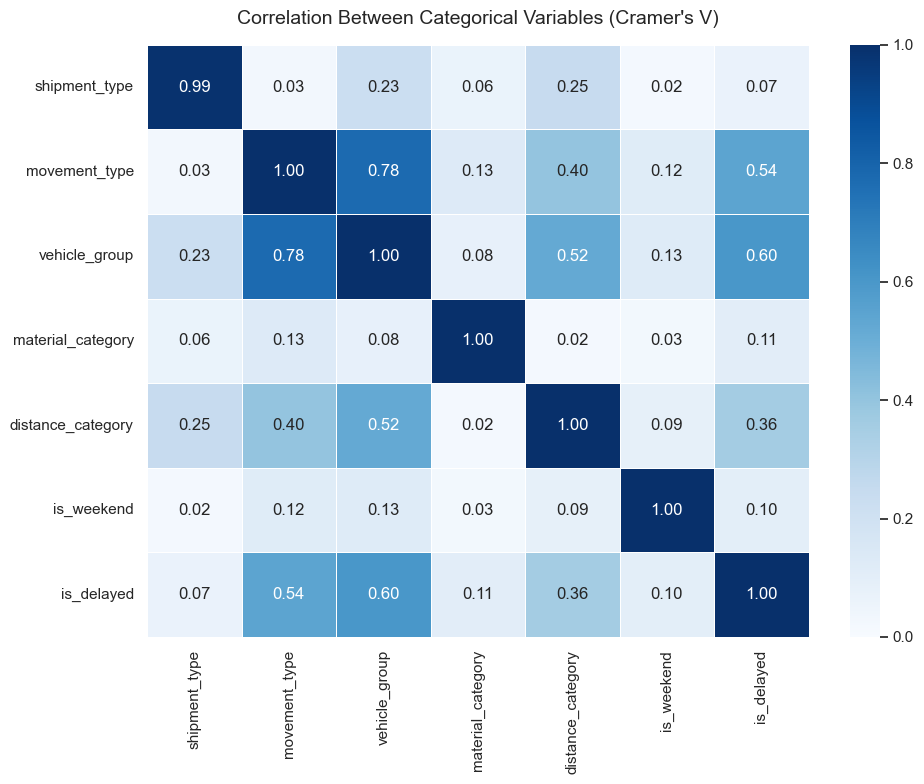

In [273]:
# Cramer' V (Bergsma & Wicher, 2013)
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    denominator = min(kcorr - 1, rcorr - 1)
    if denominator <= 0:
        return 0.0
        
    return np.sqrt(phi2corr / denominator)

cat_cols = ['shipment_type', 'movement_type', 'vehicle_group', 'material_category', 'distance_category', 'is_weekend']

print("--- CHI-SQUARE TEST RESULTS (P-VALUES) ---")

for col in cat_cols:
    print(f"- H0: {col} have effect on delay rate")
    if col in df.columns:
        contingency_table = pd.crosstab(df[col], df['is_delayed'])
        chi2, p_val, dof, expected = ss.chi2_contingency(contingency_table)
        
        significance = "Reject H0\n" if p_val < 0.05 else "No reject H0\n"
        print(f"- {col.ljust(15)}: p-value = {p_val:.4e} => {significance}")
        
        # Expected frequency >= 5
        pct_low = (expected < 5).sum() / expected.size * 100
        if pct_low > 20:
            print(f"  WARNING: {pct_low:.1f}%number of record expected < 5 -> Chi-Square may not reliable.\n")

cat_cols_with_target = cat_cols + ['is_delayed']
existing_cols = [col for col in cat_cols_with_target if col in df.columns]

cramer_matrix = pd.DataFrame(np.zeros((len(existing_cols), len(existing_cols))), 
                             index=existing_cols, columns=existing_cols)

for col1 in existing_cols:
    for col2 in existing_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="Blues", 
            vmin=0, vmax=1, 
            linewidths=0.5)

plt.title("Correlation Between Categorical Variables (Cramer's V)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

> Through bviriate analysis for categorical varibales, Movement Type (Intra City - Inter City), Vehicle Group, and Distance are significantly affect the on-time rate

In [ ]:
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

supplier_stats = df.groupby('supplier_name').agg(
    total_trips=('booking_id', 'count'),
    ontime_trips=('ontime', lambda x: (x == 'Yes').sum()),
    median_dist_km=('transportation_distance_km', 'median'),
    median_sla=('planned_eta', 'median'),
    main_shipment_type=('shipment_type', get_mode),
    main_movement=('movement_type', get_mode),
    top_route=('route_name', get_mode),
    top_vehicle=('vehicle_type', get_mode),
    top_material=('material_shipped', get_mode) 
).reset_index()

supplier_stats['ontime_rate_%'] = (supplier_stats['ontime_trips'] / supplier_stats['total_trips']) * 100

filtered_suppliers = supplier_stats[supplier_stats['total_trips'] > 50]

# Worst supplier
bottom_5_suppliers = filtered_suppliers.sort_values(by='ontime_rate_%', ascending=True).head(5)

bottom_5_suppliers['ontime_rate_%'] = bottom_5_suppliers['ontime_rate_%'].round(2)
bottom_5_suppliers['median_dist_km'] = bottom_5_suppliers['median_dist_km'].round(1)

# Best supplier
top_5_suppliers = filtered_suppliers.sort_values(by='ontime_rate_%', ascending=False).head(5)

top_5_suppliers['ontime_rate_%'] = top_5_suppliers['ontime_rate_%'].round(2)
top_5_suppliers['median_dist_km'] = top_5_suppliers['median_dist_km'].round(1)

display_cols = [
    'supplier_name', 'total_trips', 'ontime_rate_%', 
    'main_movement', 'main_shipment_type', 'median_dist_km', 'median_sla', 
    'top_route', 'top_vehicle', 'top_material'
]

print("-- Top 5 worst supplier --")
print(bottom_5_suppliers[display_cols].to_string(index=False))


print("\n-- Top 5 best supplier --")
print(top_5_suppliers[display_cols].to_string(index=False))

-- Top 5 worst supplier --
                supplier_name  total_trips  ontime_rate_% main_movement main_shipment_type  median_dist_km      median_sla                                                              top_route                 top_vehicle top_material
            Rajdhani Roadways           64           0.00    Inter city            Regular          1178.0 1 days 04:19:30                   Shive, pune, maharashtra - Sirohi, Jaipur, Rajasthan 32 FT Single-Axle 7MT - HCV   Auto Parts
    K.Ramachandran Transports           61           1.64    Inter city            Regular            90.0 1 days 07:37:00      Manali, tiruvallur, tamil nadu - Thaiyur, Kanchipuram, Tamil Nadu      40 FT 3XL Trailer 35MT   Auto Parts
                      Unknown          215           2.33    Inter city            Regular           667.0 1 days 06:15:00                  Kollur, medak, telangana - Lakdaram, Medak, Telangana        19 FT Open 7MT - MCV   Auto Parts
            Trans Cargo India    

### SLA

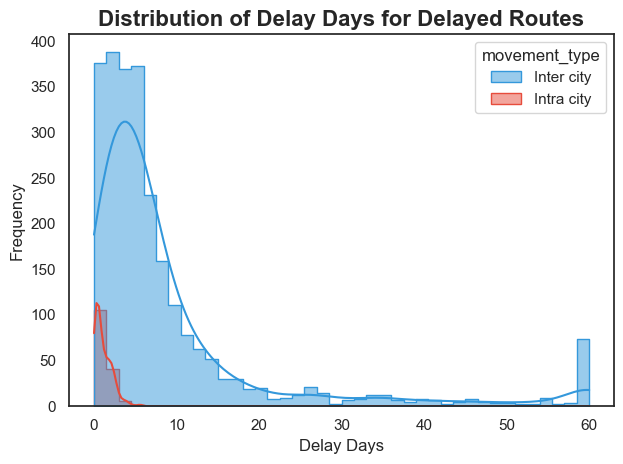

               count         max       min    median       mean        std
movement_type                                                             
Inter city      2558  207.011111  0.008333  5.044792  10.836392  21.870225
Intra city       153    5.563819  0.006250  0.718125   1.126974   1.022645


In [275]:
delayed_df = df[df['delay_time_days'] > 0].copy()

delayed_df['delay_clipped'] = delayed_df['delay_time_days'].clip(upper=60)

sns.set_theme(style='white')

# Histogram of Delay Days Distribution
sns.histplot(data=delayed_df, x='delay_clipped', hue='movement_type', 
             bins=40, kde=True, palette={'Intra city': '#E74C3C', 'Inter city': '#3498DB'},
             alpha=0.5, element='step')

plt.title('Distribution of Delay Days for Delayed Routes', fontsize=16, fontweight='bold')
plt.xlabel('Delay Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print(delayed_df.groupby('movement_type')['delay_time_days'].agg(['count', 'max', 'min', 'median', 'mean', 'std']))

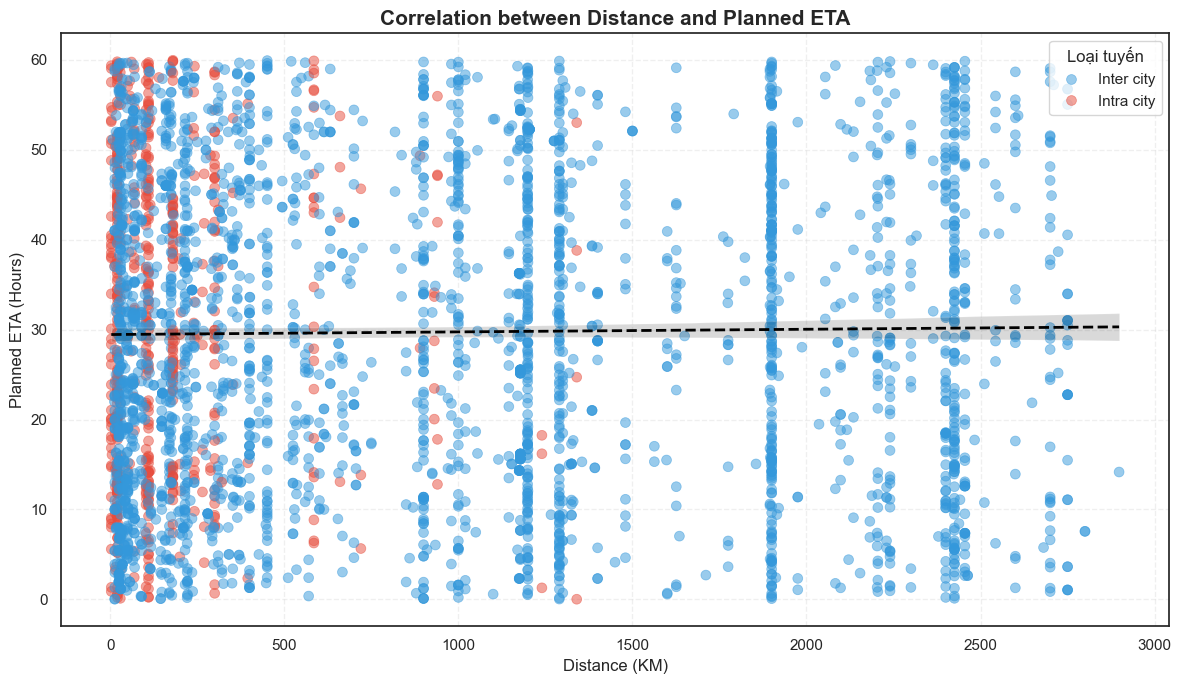

=== Correlation coefficient ===
Pearson coeficient (r) = 0.0144
=> Conclude: Have weak relationship. SLA does NOT seem to be calculated based on transportation distance.


In [276]:
df['planned_eta_hours'] = df['planned_eta'].dt.total_seconds() / 3600

sla_check_df = df[df['planned_eta_hours'] > 0].copy()

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=sla_check_df,
    x='transportation_distance_km',
    y='planned_eta_hours',
    hue='movement_type',
    palette={'Intra city': '#E74C3C', 'Inter city': '#3498DB'},
    alpha=0.5,
    edgecolor=None,
    s=50
)

sns.regplot(
    data=sla_check_df,
    x='transportation_distance_km',
    y='planned_eta_hours',
    scatter=False, 
    color='black',
    line_kws={'linestyle':'--', 'linewidth': 2}
)

plt.title('Correlation between Distance and Planned ETA', fontsize=15, fontweight='bold')
plt.xlabel('Distance (KM)', fontsize=12)
plt.ylabel('Planned ETA (Hours)', fontsize=12)
plt.legend(title='Loại tuyến', fontsize=11)
plt.grid(axis='both', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

correlation = sla_check_df['transportation_distance_km'].corr(sla_check_df['planned_eta_hours'])

print("=== Correlation coefficient ===")
print(f"Pearson coeficient (r) = {correlation:.4f}")

if abs(correlation) < 0.3:
    print("=> Conclude: Have weak relationship. SLA does NOT seem to be calculated based on transportation distance.")
elif abs(correlation) < 0.7:
    print("=> Conclude: Have moderate relationship.")
else:
    print("=> Conclude: Have strong relationship. SLA has a strong correlation with transportation distance.")

### Fleet Allocation

In [277]:
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

delayed_df = df[df['delay_time_days'] > 0]

total_stats = df.groupby('supplier_name').agg(
    total_trips=('booking_id', 'count')
).reset_index()

delayed_base_stats = delayed_df.groupby('supplier_name').agg(
    delayed_trips=('booking_id', 'count'),
    median_delay_days=('delay_time_days', 'median'),
    mainly_movement_type=('movement_type', get_mode)
).reset_index()

total_veh = df.groupby(['supplier_name', 'vehicle_type']).size().reset_index(name='total_veh_trips')

delayed_veh = delayed_df.groupby(['supplier_name', 'vehicle_type']).agg(
    count=('booking_id', 'count'),
    median_dist=('transportation_distance_km', 'median')
).reset_index()

veh_stats = pd.merge(delayed_veh, total_veh, on=['supplier_name', 'vehicle_type'], how='left')
veh_stats['rate_%'] = ((veh_stats['count'] / veh_stats['total_veh_trips']) * 100).round(1)
veh_stats['median_dist'] = veh_stats['median_dist'].round(1)

veh_stats = veh_stats.sort_values(['supplier_name', 'count'], ascending=[True, False])
veh_stats['rank'] = veh_stats.groupby('supplier_name').cumcount() + 1
top3_veh = veh_stats[veh_stats['rank'] <= 3]

fleet_stats = top3_veh.pivot(index='supplier_name', columns='rank', values=['vehicle_type', 'count', 'rate_%', 'median_dist'])

col_map = {
    'vehicle_type': 'vehicle',
    'count': 'count',
    'rate_%': 'rate',
    'median_dist': 'dist'
}

fleet_stats.columns = [f"{col_map.get(col[0], col[0])}_{col[1]}" 
                        for col in fleet_stats.columns]
                
fleet_stats = fleet_stats.rename(columns=lambda x: x.replace('rate_%_', 'rate_').replace('median_dist_', 'dist_')).reset_index()

delayed_full_stats = pd.merge(delayed_base_stats, fleet_stats, on='supplier_name', how='left')
supplier_breakdown = pd.merge(total_stats, delayed_full_stats, on='supplier_name', how='left')

supplier_breakdown['delay_rate_%'] = ((supplier_breakdown['delayed_trips'] / supplier_breakdown['total_trips']) * 100).round(2)

supplier_breakdown = supplier_breakdown[supplier_breakdown['total_trips'] > 50]

top_10_delayed = supplier_breakdown.sort_values('delayed_trips', ascending=False).head(10).copy()

top_10_delayed['median_delay_days'] = top_10_delayed['median_delay_days'].round(1)

display_cols = [
    'supplier_name', 'total_trips', 'delayed_trips', 'delay_rate_%', 
    'median_delay_days', 'mainly_movement_type',
    'vehicle_1', 'count_1', 'rate_1', 'dist_1',
    'vehicle_2', 'count_2', 'rate_2', 'dist_2',
    'vehicle_3', 'count_3', 'rate_3', 'dist_3'
]

for i in range(1, 4):
    for prefix in ['vehicle_', 'count_', 'rate_', 'dist_']:
        col_name = f"{prefix}{i}"
        if col_name not in top_10_delayed.columns:
            top_10_delayed[col_name] = None

print("\n--- TOP 10 SUPPLIERS BY DELAYED TRIP ---")
print(top_10_delayed[display_cols].to_string(index=False))


--- TOP 10 SUPPLIERS BY DELAYED TRIP ---
                    supplier_name  total_trips  delayed_trips  delay_rate_%  median_delay_days mainly_movement_type                                vehicle_1 count_1 rate_1  dist_1                                vehicle_2 count_2 rate_2  dist_2                                 vehicle_3 count_3 rate_3  dist_3
           Ekta Transport Company          237          226.0         95.36                4.7           Inter city              32 FT Multi-Axle 14MT - HCV     157   95.2  2135.0              32 FT Single-Axle 7MT - HCV      69   95.8  1900.0                                       NaN     NaN    NaN     NaN
                          Unknown          215          210.0         97.67                8.1           Inter city                     19 FT Open 7MT - MCV      63  100.0   667.0                   40 FT 3XL Trailer 35MT      59   98.3    70.0               32 FT Multi-Axle 14MT - HCV      58   95.1  2125.5
                Trans Cargo Ind

--- Fleet Distribution (Volume) ---
vehicle_group  Container  HCV (Heavy Commercial)  Heavy Trailer (>20MT)  \
movement_type                                                             
Inter city            85                    1499                    921   
Intra city             0                       1                     10   
All                   85                    1500                    931   

vehicle_group  LCV (Light Commercial)  MCV (Medium Commercial)  \
movement_type                                                    
Inter city                         29                      130   
Intra city                          0                        0   
All                                29                      130   

vehicle_group  Others / Not Specified   All  
movement_type                                
Inter city                        269  2933  
Intra city                        582   593  
All                               851  3526  

--- Fleet Distribution ---

<Figure size 1200x700 with 0 Axes>

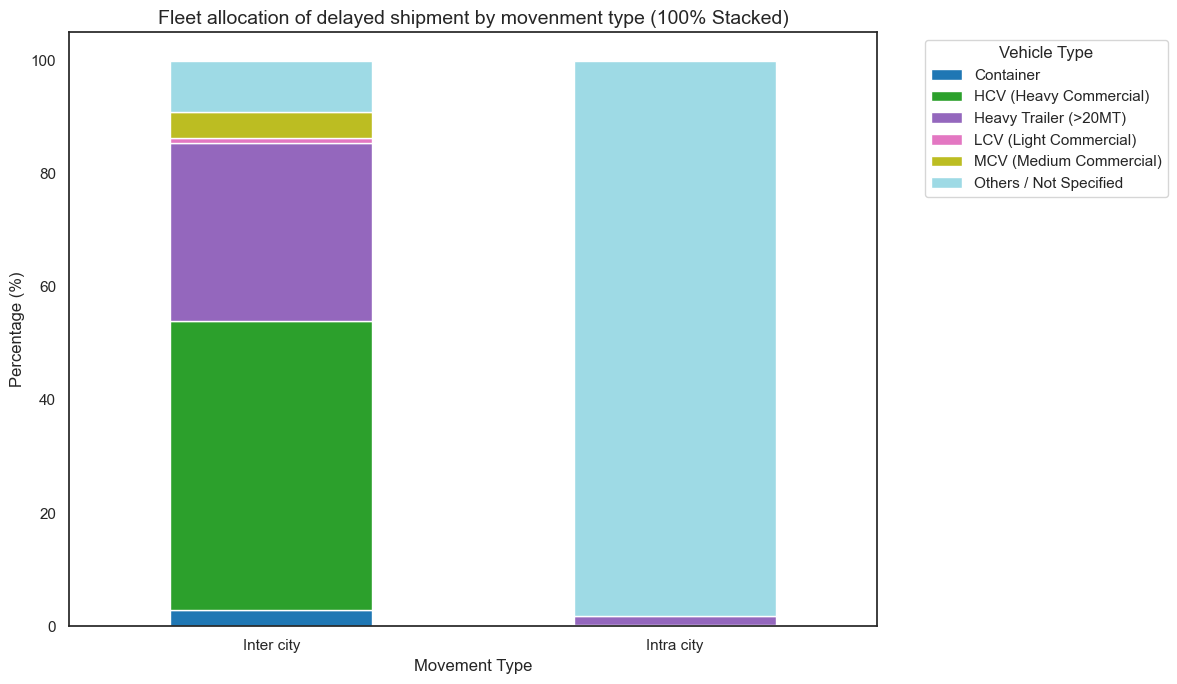

In [278]:
top_vehicles = df['vehicle_group'].value_counts().nlargest(7).index.tolist()

cross_tab = pd.crosstab(df['movement_type'], df['vehicle_group'], margins=True)
print("--- Fleet Distribution (Volume) ---")
print(cross_tab)

cross_tab_pct = pd.crosstab(df['movement_type'], df['vehicle_group'], normalize='index') * 100

plt.figure(figsize=(12, 7))
cross_tab_pct.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12, 7))
plt.title('Fleet allocation of delayed shipment by movenment type (100% Stacked)', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Movement Type', fontsize=12)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

print("\n--- Fleet Distribution ---")
for cat in ['Intra city', 'Inter city']:
    subset = df[df['movement_type'] == cat]
    top_veh = subset['vehicle_group'].value_counts().head(5)
    print(f"\n[{cat}] (Tổng: {len(subset)} chuyến)")
    print(top_veh.to_string())

### Movement Type

In [ ]:
from scipy.stats import chi2_contingency

df['ontime_numeric'] = df['ontime'].map({'Yes': 1, 'No': 0})

contingency_table = pd.crosstab(df['shipment_type'], df['ontime'])
print("--- CONTINGENCY TABLE ---")
print(contingency_table)

delay_rate = df.groupby('shipment_type')['ontime_numeric'].mean() * 100
print("\n--- DELAY RATE BY SHIPMENT TYPE (%) ---")
print(delay_rate.round(2))

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

alpha = 0.05
print("\n--- CONCLUSION ---")
if p_val < alpha:
    print("Reject Null Hypothesis.")
    print("The relationship between Movement Type and Delay rate IS significant.")
else:
    print("Fail to Reject Null Hypothesis.")
    print("The relationship between Movement Type and Delay rate IS NOT statistically significant.")

--- CONTINGENCY TABLE ---
ontime           No  Yes
shipment_type           
Market           31   27
Regular        2680  788

--- DELAY RATE BY SHIPMENT TYPE (%) ---
shipment_type
Market     46.55
Regular    22.72
Name: ontime_numeric, dtype: float64

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 16.9118
P-value: 3.9158e-05

--- CONCLUSION ---
Reject Null Hypothesis.
Có mối liên hệ MANG TÍNH THỐNG KÊ giữa Shipment Type và việc trễ hạn.


In [281]:
pd.crosstab(df['shipment_type'], df['movement_type'], normalize='index') * 100

movement_type,Inter city,Intra city
shipment_type,,
Market,72.413793,27.586207
Regular,83.362168,16.637832


In [285]:
# Chỉ Inter-city
inter = df[df['movement_type'] == 'Inter city']
print("\n--- INTER-CITY CONTINGENCY TABLE ---")
inter_contigency = pd.crosstab(inter['shipment_type'], inter['ontime'])
print(inter_contigency)

chi2_stat, p_val, dof, expected = chi2_contingency(inter_contigency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Chỉ Intra-city  
intra = df[df['movement_type'] == 'Intra city']
print("\n--- INTRA-CITY CONTINGENCY TABLE ---")
intra_contingency = pd.crosstab(intra['shipment_type'], intra['ontime'])
print(intra_contingency)

chi2_stat, p_val, dof, expected = chi2_contingency(intra_contingency)

print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")


--- INTER-CITY CONTINGENCY TABLE ---
ontime           No  Yes
shipment_type           
Market           25   17
Regular        2533  358

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 26.8351
P-value: 2.2158e-07

--- INTRA-CITY CONTINGENCY TABLE ---
ontime          No  Yes
shipment_type          
Market           6   10
Regular        147  430

--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 0.6314
P-value: 4.2683e-01


In [283]:
from statsmodels.stats.proportion import proportion_confint
low, high = proportion_confint(25, 42, alpha=0.05, method='wilson')
print(f"Market inter-city delay rate CI: {low*100:.1f}% to {high*100:.1f}%")   

low, high = proportion_confint(2533, 2819, alpha=0.05, method='wilson')
print(f"Regular inter-city delay rate CI: {low*100:.1f}% to {high*100:.1f}%")

Market inter-city delay rate CI: 44.5% to 73.0%
Regular inter-city delay rate CI: 88.7% to 90.9%


In [290]:
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Unknown'

target_df = df[(df['shipment_type'] == 'Regular') & (df['movement_type'] == 'Inter city')].copy()

target_df['numerical_ontime'] = target_df['ontime'].map({'Yes': 0, 'No': 1})

regular_inter_stats = target_df.groupby('supplier_name').agg(
    total_trips=('booking_id', 'count'),
    delayed_trips=('numerical_ontime', 'sum'),
    median_dist_km=('transportation_distance_km', 'median'),
    top_vehicle=('vehicle_type', get_mode),
    top_material=('material_shipped', get_mode)
).reset_index()

regular_inter_stats['delay_rate_%'] = ((regular_inter_stats['delayed_trips'] / regular_inter_stats['total_trips']) * 100).round(1)

delayed_only = target_df[target_df['ontime'] == 'No'].groupby('supplier_name').agg(
    median_delay_days=('delay_time_days', 'median')
).reset_index()

final_stats = pd.merge(regular_inter_stats, delayed_only, on='supplier_name', how='left')
final_stats['median_delay_days'] = final_stats['median_delay_days'].round(1).fillna(0)
final_stats['median_dist_km'] = final_stats['median_dist_km'].round(1)

final_stats = final_stats[final_stats['total_trips'] >= 50]

final_stats = final_stats.sort_values(by=['delayed_trips', 'delay_rate_%'], ascending=[False, False])

display_cols = [
    'supplier_name', 'total_trips', 'delayed_trips', 'delay_rate_%', 
    'median_delay_days', 'median_dist_km', 'top_vehicle', 'top_material'
]

print("\n--- ATTRIBUTES OF 'REGULAR' SUPPLIERS ON 'INTER-CITY' ROUTES ---")
print(final_stats[display_cols].to_string(index=False))


--- ATTRIBUTES OF 'REGULAR' SUPPLIERS ON 'INTER-CITY' ROUTES ---
                      supplier_name  total_trips  delayed_trips  delay_rate_%  median_delay_days  median_dist_km                              top_vehicle top_material
             Ekta Transport Company          237            226          95.4                4.7          1900.0              32 FT Multi-Axle 14MT - HCV   Auto Parts
                            Unknown          215            210          97.7                8.1           667.0                     19 FT Open 7MT - MCV   Auto Parts
                  Trans Cargo India          195            189          96.9                5.3          2400.0              32 FT Multi-Axle 14MT - HCV   Auto Parts
    Sunita Carriers Private Limited          158            144          91.1                5.1           210.0 40 FT Flat Bed Multi-Axle 27MT - Trailer   Auto Parts
                      Krc Logistics          161            143          88.8                4.9   

In [ ]:
mismatch_suppliers = [
    'A P R Trailler Service',
    'K.Ramachandran Transports',
    'Baba Lingaraj Enterprises Pvt Ltd',
    'Rajdhani Roadways',
    'Sunita Carriers Private Limited',
    'As Logistics',
    'Shri Ganesh Traders And Transporter'
]

inter_city_df = df[df['movement_type'] == 'Inter city'].copy()

clean_df = inter_city_df[~((inter_city_df['shipment_type'] == 'Regular') & 
                           (inter_city_df['supplier_name'].isin(mismatch_suppliers)))]

contingency_table_clean = pd.crosstab(clean_df['shipment_type'], clean_df['is_delayed'])

delay_rate_clean = clean_df.groupby('shipment_type')['is_delayed'].mean() * 100

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table_clean)

print("--- CLEANED INTER-CITY CONTINGENCY TABLE ---")
print(contingency_table_clean)

print("\n--- NEW DELAY RATE (%) ---")
print(delay_rate_clean.round(1))

print("\n--- NEW CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha:
    print("Conclusion: There is a significant relationship between Shipment Type and Delay rate.")
else:
    print("Conclusion: There is no significant relationship between Shipment Type and Delay rate.")

--- CLEANED INTER-CITY CONTINGENCY TABLE ---
is_delayed       0     1
shipment_type           
Market          17    25
Regular        315  1974

--- NEW DELAY RATE (%) ---
shipment_type
Market     59.5
Regular    86.2
Name: is_delayed, dtype: float64

--- NEW CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 21.9608
P-value: 2.7827e-06
Kết luận: Vẫn có sự khác biệt thống kê giữa Market và Regular (Cleaned).
